---
title: Laplace transform
---

The Laplace transform converts a function of time $f(t)$ into a function of a complex variable $s$:

$$\mathcal{L}\{f(t)\} = F(s) = \int_0^{\infty} f(t) \, e^{-st} \, dt$$

**What it actually does**

Think of it as decomposing a signal into a basis of exponentially decaying (or growing) oscillations $e^{st}$ where $s = \sigma + i\omega$. The real part $\sigma$ captures growth/decay rates, while the imaginary part $\omega$ captures oscillation frequencies. This generalizes the Fourier transform, which only handles pure oscillations.

**Why it's useful**

The transform turns calculus into algebra. Differentiation becomes multiplication:
$$\mathcal{L}\{f'(t)\} = sF(s) - f(0)$$

This means differential equations become polynomial equations in $s$, which are far easier to solve. You transform, solve algebraically, then invert back.

**Key properties**

- Linearity: $\mathcal{L}\{af + bg\} = aF + bG$
- Convolution becomes multiplication: $\mathcal{L}\{f * g\} = F(s)G(s)$
- Time shifting: $\mathcal{L}\{f(t-a)\} = e^{-as}F(s)$

**Connection to your work**

For phase-type distributions, the Laplace transform is central. If $T \sim \text{PH}(\boldsymbol{\alpha}, \mathbf{S})$, its transform is:

$$\mathcal{L}\{f_T\}(s) = \boldsymbol{\alpha}(s\mathbf{I} - \mathbf{S})^{-1}\mathbf{s}$$

This matrix form makes computations tractable—moments, convolutions, and fitting all become linear algebra rather than integrals. The transform essentially encodes the entire distribution in a compact algebraic object.

Want me to go deeper on any aspect—the inversion formula, specific applications in PH distributions, or the connection to moment generating functions?

## Phase-type distributions

In the matrix formulation, the Laplace transform for a continuous phase-type distribution is defined as:

$E[e^{-\theta \tau}] = \mathbf{\alpha} (\theta\, \mathbf{I} − \mathbf{S})^{−1}\mathbf{s}$

where $\mathbf{s}$ is a vector of ones for states with non-zero rates to absorbing states and zeros otherwise. The $\theta$ is time-homogeneous so it can only represent a global mutation rate if there are only two sequences. 

In the example below, we let it represetn a recombination rate in an ARG so we can compute the probability that two loci separated by a recombination distance $\theta$ are represented by the same tree in our sample. I.e., that no recombination has occurred on the branches of the tree at locus1 one at any of the positions between locus one and two.

In [1]:
from phasic import Graph, with_ipv
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from vscodenb import set_vscode_theme
sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)


In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

## Matrix-based computation

Specification in matrix terms:

In [3]:
S = np.array([[-6, 6, 0, 0], 
              [0, -3, 1, 2], 
              [0, 0, -1, 0], 
              [0, 0, 0, -1]], dtype=float)
alpha = np.array([1, 0, 0, 0], dtype=float)  # starting state
n = len(alpha)

Matrix computation of Laplace transform:

In [4]:
theta = 0.5

s0 = -S @ np.ones(n)
laplace_result = np.linalg.solve(theta * np.eye(n) - S, s0)
print(laplace_result)

[0.52747253 0.57142857 0.66666667 0.66666667]


Laplace transform by modifying S:

In [5]:
S_new = S - theta * np.eye(n)
print("Modified S matrix:")
print(S_new)

Modified S matrix:
[[-6.5  6.   0.   0. ]
 [ 0.  -3.5  1.   2. ]
 [ 0.   0.  -1.5  0. ]
 [ 0.   0.   0.  -1.5]]


## Laplace transformation as graph operations

In the phasic library, Laplace transform can be implemented by:
1. Adding edges from each transient state to the absorbing state with weight θ
2. Creating a reward vector that is 1 for states with edges to absorption
3. Computing expectations using reward transformation

This is equivalent to the matrix formulation: $E[e^{-\theta \tau}] = \mathbf{\alpha} (\theta\, \mathbf{I} − \mathbf{S})^{−1}\mathbf{s}$

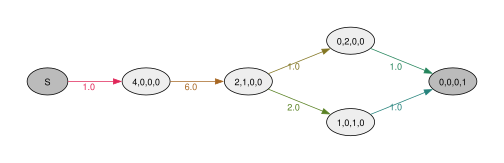

In [6]:
graph = Graph(coalescent)
graph.plot()

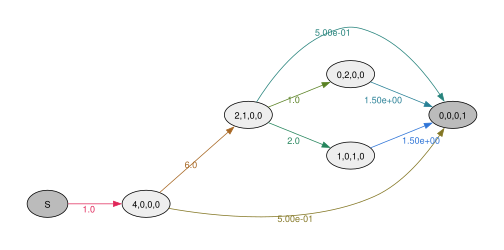

In [7]:
#| label: fig-laplace-transform
lap_graph = graph.laplace_transform(theta)
lap_graph.plot()

In [8]:
theta = 0.5
rewards = graph.absorbing_state_rewards()
lap_graph.expected_waiting_time(rewards)

[0.5274725274725275,
 0.5274725274725275,
 0.5714285714285714,
 0.6666666666666666,
 0.6666666666666666,
 0.0]

### Expectation and Variance

In [9]:
lap_graph.expectation(rewards), lap_graph.variance(rewards)

(0.5274725274725275, 0.4250694360584471)

### Higher moments

In [10]:
lap_graph.moments(5)

[0.945054945054945,
 1.4462021494988528,
 3.0644279039400404,
 8.376088953712031,
 28.218036661593192]

### PDF

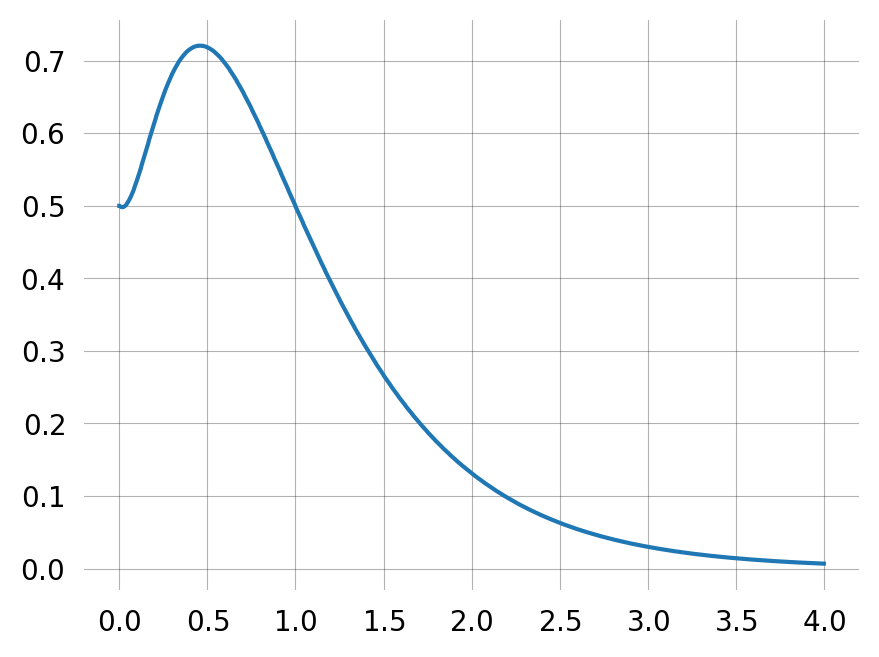

In [11]:
#| label: fig-laplace-pdf
time = np.arange(0, 4, 0.001)
pdf = lap_graph.pdf(time)
plt.plot(time, pdf)
plt.show()